# ThreatInk — Spam Message Detection
## COS30049 Computing Technology Innovation Project | Assignment 2
**Group 5** | Yan Min Xuan Shanice · Soh Way Miin · Tan Jun Xiong

---
### Notebook Structure
1. Environment Setup & Imports  
2. Data Collection  
3. Data Processing & Feature Engineering  
4. Exploratory Data Analysis (EDA)  
5. Machine Learning — Classification Models  
6. Machine Learning — Regression Model  
7. Machine Learning — Clustering  
8. Model Comparison & Evaluation  
9. Export Processed Data & Models  


## 1. Environment Setup & Imports

In [1]:
# ── Standard libraries ──────────────────────────────────
import warnings, re, string, os, joblib
warnings.filterwarnings('ignore')

# ── Data handling ────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud

# ── NLP ──────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

# ── Feature extraction ───────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# ── ML — Classification ──────────────────────────────────
from sklearn.naive_bayes     import MultinomialNB
from sklearn.linear_model    import LogisticRegression
from sklearn.svm             import LinearSVC
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree            import DecisionTreeClassifier

# ── ML — Regression ──────────────────────────────────────
from sklearn.linear_model    import Ridge
from sklearn.ensemble        import GradientBoostingRegressor

# ── ML — Clustering ──────────────────────────────────────
from sklearn.cluster         import KMeans
from sklearn.decomposition   import TruncatedSVD

# ── Model utilities ──────────────────────────────────────
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import LabelEncoder, MinMaxScaler
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score
)

# ── Plot style ───────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
})
PALETTE = {'ham': '#2563eb', 'spam': '#ef4444'}
print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


## 2. Data Collection

### Dataset Sources
| # | Dataset | Source | Records | Type |
|---|---------|--------|---------|------|
| 1 | Lecturer Basic Dataset (emails.csv) | Canvas / Course Material | 5,728 | Email text + binary label |
| 2 | UCI SMS Spam Collection | [Kaggle - team-ai](https://www.kaggle.com/datasets/team-ai/spam-text-message-classification) | 5,572 | SMS text + label |
| 3 | Combined Spam Dataset | [Kaggle - meruvulikith](https://www.kaggle.com/datasets/meruvulikith/190k-spam-or-not-spam-dataset) | 83,448 | Email text + binary label |

**Note:** Three datasets are merged to create a comprehensive and diverse training corpus, improving model generalisation across both email and SMS spam patterns.


In [2]:
# ── Load Dataset 1: Lecturer Basic Dataset ──────────────
df_email = pd.read_csv('../data/emails.csv')
df_email['source'] = 'email_lecturer'
print(f"Dataset 1 (Lecturer emails.csv) loaded: {df_email.shape[0]:,} rows")
print(f"Columns: {df_email.columns.tolist()}")
print(f"Label distribution:")
print(df_email['spam'].value_counts().rename({0:'Ham', 1:'Spam'}))
print(df_email.head(3))


Dataset 1 (Lecturer emails.csv) loaded: 5,728 rows
Columns: ['text', 'spam', 'source']
Label distribution:
spam
Ham     4360
Spam    1368
Name: count, dtype: int64
                                                text  spam          source
0  Subject: naturally irresistible your corporate...     1  email_lecturer
1  Subject: the stock trading gunslinger  fanny i...     1  email_lecturer
2  Subject: unbelievable new homes made easy  im ...     1  email_lecturer


In [3]:
# ── Load Dataset 2: UCI SMS Spam Collection (Kaggle) ────
try:
    df_sms = pd.read_csv('../data/SPAM text message 20170820 - Data.csv')
    df_sms.columns = df_sms.columns.str.strip()
    df_sms = df_sms.rename(columns={'Category': 'spam', 'Message': 'text'})
    df_sms['spam'] = (df_sms['spam'] == 'spam').astype(int)
    df_sms['source'] = 'sms_uci'
    print(f"Dataset 2 (UCI SMS) loaded: {df_sms.shape[0]:,} rows")
    print(f"Label distribution:")
    print(df_sms['spam'].value_counts().rename({0:'Ham', 1:'Spam'}))
    USE_SMS = True
except Exception as e:
    print(f"Warning: Could not load SMS dataset: {e}")
    df_sms = pd.DataFrame(columns=['text', 'spam', 'source'])
    USE_SMS = False

print()

# ── Load Dataset 3: Kaggle Combined Spam Dataset ─────────
try:
    df_combined = pd.read_csv('../data/combined_data.csv')
    df_combined = df_combined.rename(columns={'label': 'spam'})
    df_combined['source'] = 'email_kaggle'
    # Ensure text column exists
    if 'text' not in df_combined.columns:
        text_col = [c for c in df_combined.columns if c != 'spam' and c != 'source'][0]
        df_combined = df_combined.rename(columns={text_col: 'text'})
    print(f"Dataset 3 (Kaggle combined) loaded: {df_combined.shape[0]:,} rows")
    print(f"Label distribution:")
    print(df_combined['spam'].value_counts().rename({0:'Ham', 1:'Spam'}))
    USE_COMBINED = True
except Exception as e:
    print(f"Warning: Could not load combined dataset: {e}")
    df_combined = pd.DataFrame(columns=['text', 'spam', 'source'])
    USE_COMBINED = False


Dataset 2 (UCI SMS) loaded: 5,572 rows
Label distribution:
spam
Ham     4825
Spam     747
Name: count, dtype: int64

Dataset 3 (Kaggle combined) loaded: 83,448 rows
Label distribution:
spam
Spam    43910
Ham     39538
Name: count, dtype: int64


In [4]:
# ── Merge all 3 datasets ─────────────────────────────────
dfs_to_merge = [df_email]
if USE_SMS:
    dfs_to_merge.append(df_sms)
if USE_COMBINED:
    dfs_to_merge.append(df_combined)

df_raw = pd.concat(dfs_to_merge, ignore_index=True)

# Keep only needed columns
df_raw = df_raw[['text', 'spam', 'source']].copy()

print("=" * 55)
print("MERGED DATASET SUMMARY")
print("=" * 55)
print(f"Total records     : {df_raw.shape[0]:,}")
print(f"Columns           : {df_raw.columns.tolist()}")
print()
print("Source breakdown:")
src_counts = df_raw['source'].value_counts()
for src, cnt in src_counts.items():
    print(f"  {src:<20} {cnt:>7,} rows")
print()
print("Label distribution:")
lbl = df_raw['spam'].value_counts().rename({0:'Ham (legitimate)', 1:'Spam'})
print(lbl)
print(f"\nSpam rate         : {df_raw['spam'].mean():.1%}")
print(f"Ham rate          : {(1-df_raw['spam'].mean()):.1%}")


MERGED DATASET SUMMARY
Total records     : 94,748
Columns           : ['text', 'spam', 'source']

Source breakdown:
  email_kaggle          83,448 rows
  email_lecturer         5,728 rows
  sms_uci                5,572 rows

Label distribution:
spam
Ham (legitimate)    48723
Spam                46025
Name: count, dtype: int64

Spam rate         : 48.6%
Ham rate          : 51.4%


## 3. Data Processing & Feature Engineering

In [5]:
# ── 3.1 Basic cleaning ───────────────────────────────────
df = df_raw.copy()

# Remove duplicates
before = len(df)
df.drop_duplicates(subset='text', inplace=True)
print(f"Removed {before - len(df)} duplicate rows")

# Drop rows with empty text
df.dropna(subset=['text'], inplace=True)
df = df[df['text'].str.strip().str.len() > 0]

# Reset index
df.reset_index(drop=True, inplace=True)
print(f"Clean dataset shape: {df.shape}")
print(f"Missing values:\n{df[['text','spam']].isnull().sum()}")


Removed 450 duplicate rows
Clean dataset shape: (94298, 3)
Missing values:
text    0
spam    0
dtype: int64


In [6]:
# ── 3.2 Text preprocessing function ─────────────────────
stop_words  = set(stopwords.words('english'))
stemmer     = PorterStemmer()

def preprocess_text(text: str) -> str:
    """Lowercase → strip HTML/Subject: prefix → remove punctuation →
       tokenise → remove stopwords → stem."""
    text = str(text).lower()
    text = re.sub(r'subject\s*:', '', text)          # remove email subject prefix
    text = re.sub(r'<[^>]+>', ' ', text)              # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' url ', text) # replace URLs
    text = re.sub(r'\$+', ' dollar ', text)           # replace $ signs
    text = re.sub(r'\b\d+\b', ' number ', text)       # replace standalone numbers
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [stemmer.stem(t) for t in tokens
              if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

print("Preprocessing text — this may take 30–60 seconds...")
df['text_clean'] = df['text'].apply(preprocess_text)
print(f"✅ Done. Sample:")
print(f"  Original : {df['text'].iloc[0][:100]}")
print(f"  Cleaned  : {df['text_clean'].iloc[0][:100]}")


Preprocessing text — this may take 30–60 seconds...
✅ Done. Sample:
  Original : Subject: naturally irresistible your corporate identity  lt is really hard to recollect a company : 
  Cleaned  : natur irresist corpor ident realli hard recollect compani market full suqgest inform isoverwhelminq 


In [7]:
# ── 3.3 Feature engineering ──────────────────────────────
df['char_count']       = df['text'].str.len()
df['word_count']       = df['text'].str.split().str.len()
df['exclaim_count']    = df['text'].str.count('!')
df['dollar_count']     = df['text'].str.count('\$')
df['upper_ratio']      = df['text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1))
df['url_count']        = df['text'].str.lower().str.count('http|www')
df['avg_word_len']     = df['text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0)

SPAM_KEYWORDS = ['free','win','winner','cash','prize','claim','offer',
                 'urgent','guaranteed','congratulations','click','subscribe',
                 'unlimited','bonus','discount','deal','credit','loan','earn']
df['spam_keyword_count'] = df['text'].str.lower().apply(
    lambda x: sum(1 for kw in SPAM_KEYWORDS if kw in x))

print("Engineered features:")
feature_cols = ['char_count','word_count','exclaim_count','dollar_count',
                'upper_ratio','url_count','avg_word_len','spam_keyword_count']
print(df.groupby('spam')[feature_cols].mean().round(3))


Engineered features:
      char_count  word_count  exclaim_count  dollar_count  upper_ratio  \
spam                                                                     
0       1886.665     330.630          0.261         0.372        0.005   
1       1236.414     207.898          0.595         0.460        0.002   

      url_count  avg_word_len  spam_keyword_count  
spam                                               
0         1.946         4.529               0.955  
1         0.867         5.108               1.249  


In [8]:
# ── 3.4 TF-IDF vectorisation ─────────────────────────────
TFIDF_MAX_FEATURES = 5000

tfidf = TfidfVectorizer(
    max_features = TFIDF_MAX_FEATURES,
    ngram_range  = (1, 2),   # unigrams + bigrams
    min_df       = 3,
    sublinear_tf = True
)
X_tfidf = tfidf.fit_transform(df['text_clean'])
print(f"TF-IDF matrix shape: {X_tfidf.shape}")
print(f"Vocabulary size    : {len(tfidf.vocabulary_):,}")


TF-IDF matrix shape: (94298, 5000)
Vocabulary size    : 5,000


In [9]:
# ── 3.5 Train / test split ───────────────────────────────
y = df['spam'].values

X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

# Numeric feature split (for regression + clustering)
X_numeric = df[feature_cols].values
scaler    = MinMaxScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)

X_train_num, X_test_num, _, _ = train_test_split(
    X_numeric_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set : {X_train_tfidf.shape[0]:,} samples")
print(f"Test set  : {X_test_tfidf.shape[0]:,} samples")
print(f"Spam rate in train: {y_train.mean():.2%}")
print(f"Spam rate in test : {y_test.mean():.2%}")


Train set : 75,438 samples
Test set  : 18,860 samples
Spam rate in train: 48.69%
Spam rate in test : 48.70%


## 4. Exploratory Data Analysis (EDA)

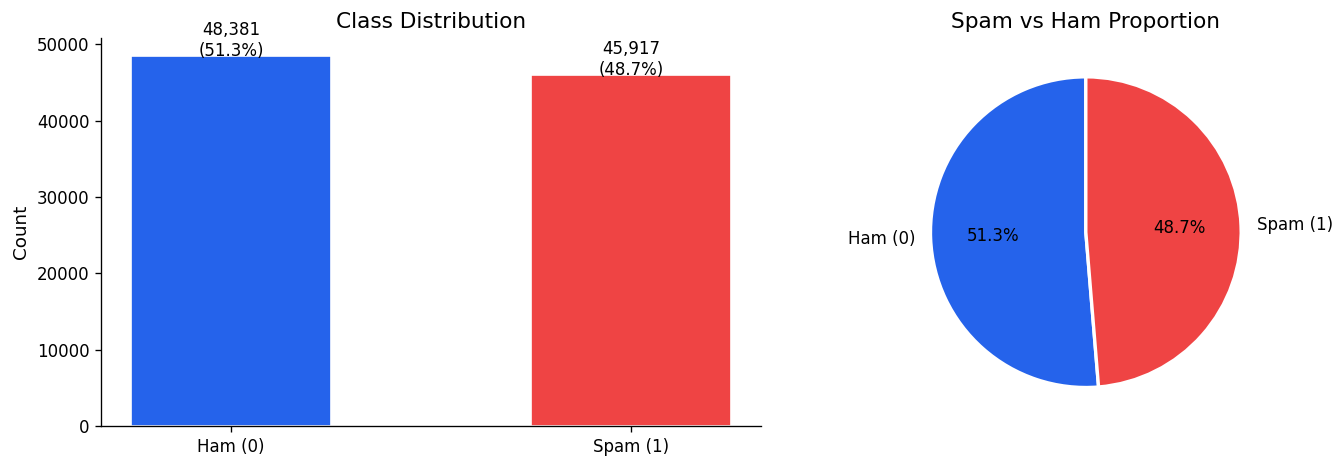

Dataset imbalance ratio — Ham : Spam = 1.1 : 1


In [10]:
# ── 4.1 Class distribution ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['spam'].value_counts().sort_index()
labels = ['Ham (0)', 'Spam (1)']
colors = [PALETTE['ham'], PALETTE['spam']]
axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, f'{v:,}\n({v/len(df):.1%})', ha='center', fontsize=10)

# Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Spam vs Ham Proportion')

plt.tight_layout()
plt.savefig('figures/01_class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Dataset imbalance ratio — Ham : Spam = {counts[0]/counts[1]:.1f} : 1")


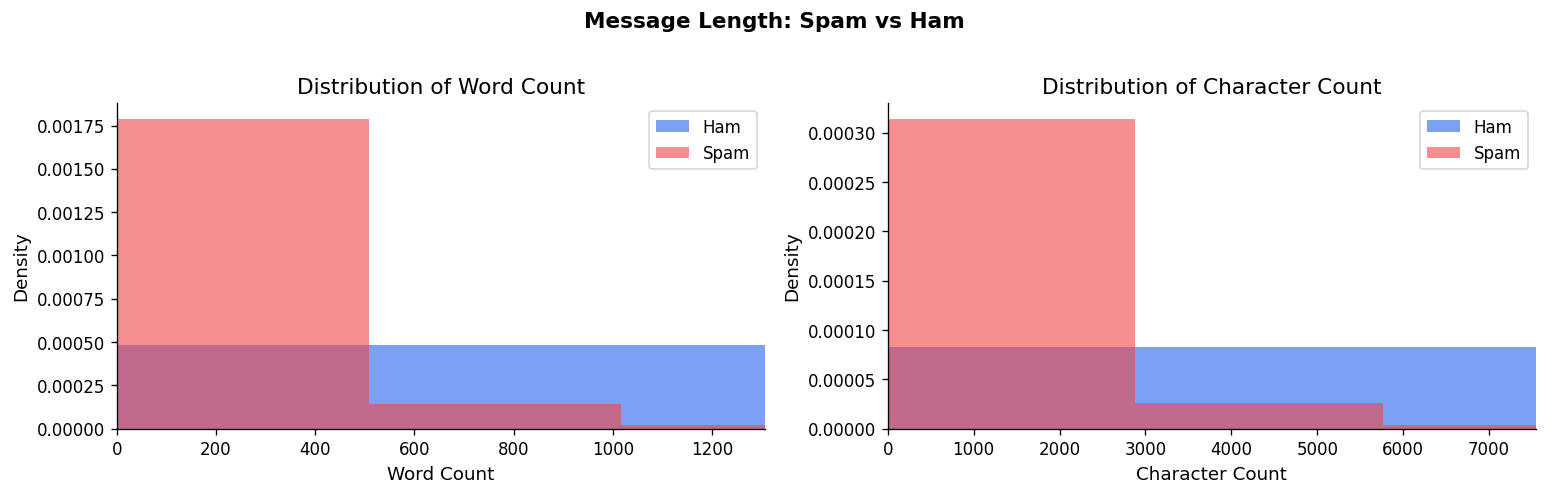

In [11]:
# ── 4.2 Message length distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, label in zip(
        axes,
        ['word_count', 'char_count'],
        ['Word Count', 'Character Count']):
    for label_val, color, name in [(0, PALETTE['ham'], 'Ham'), (1, PALETTE['spam'], 'Spam')]:
        subset = df[df['spam'] == label_val][col]
        ax.hist(subset, bins=50, alpha=0.6, color=color, label=name, density=True)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'Distribution of {label}')
    ax.legend()
    # Cap x-axis for readability
    ax.set_xlim(0, df[col].quantile(0.98))

plt.suptitle('Message Length: Spam vs Ham', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_length_distribution.png', bbox_inches='tight')
plt.show()


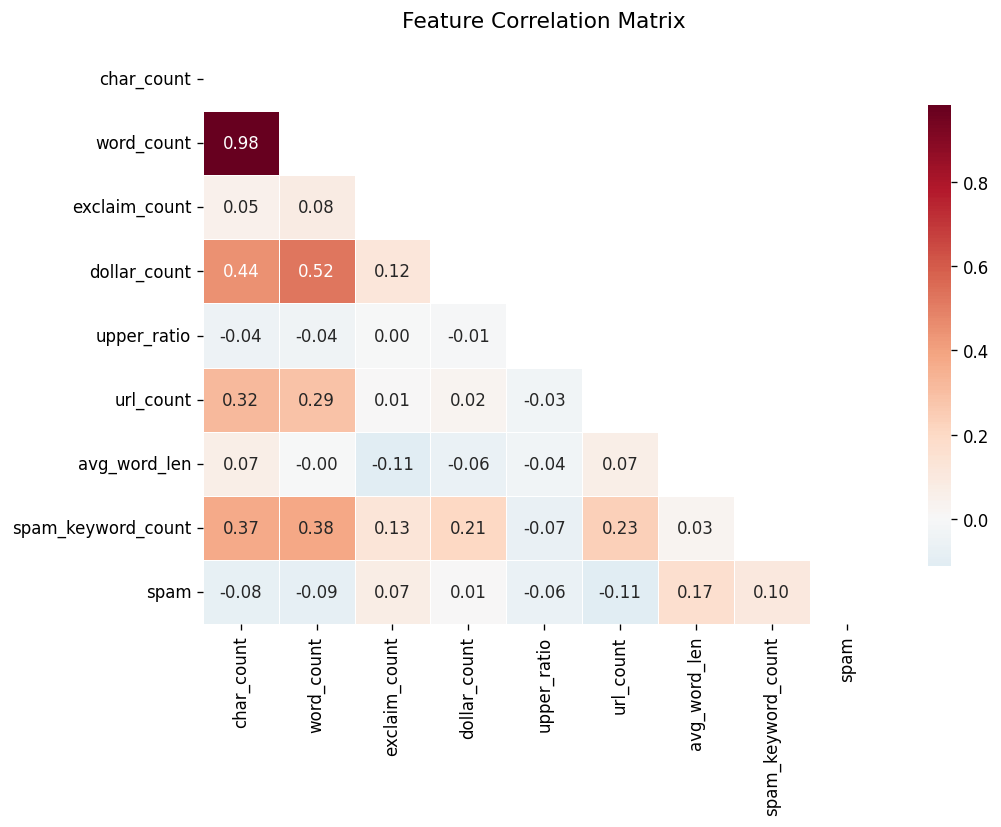

In [12]:
# ── 4.3 Feature correlation heatmap ─────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[feature_cols + ['spam']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', pad=12)
plt.tight_layout()
plt.savefig('figures/03_correlation_heatmap.png', bbox_inches='tight')
plt.show()


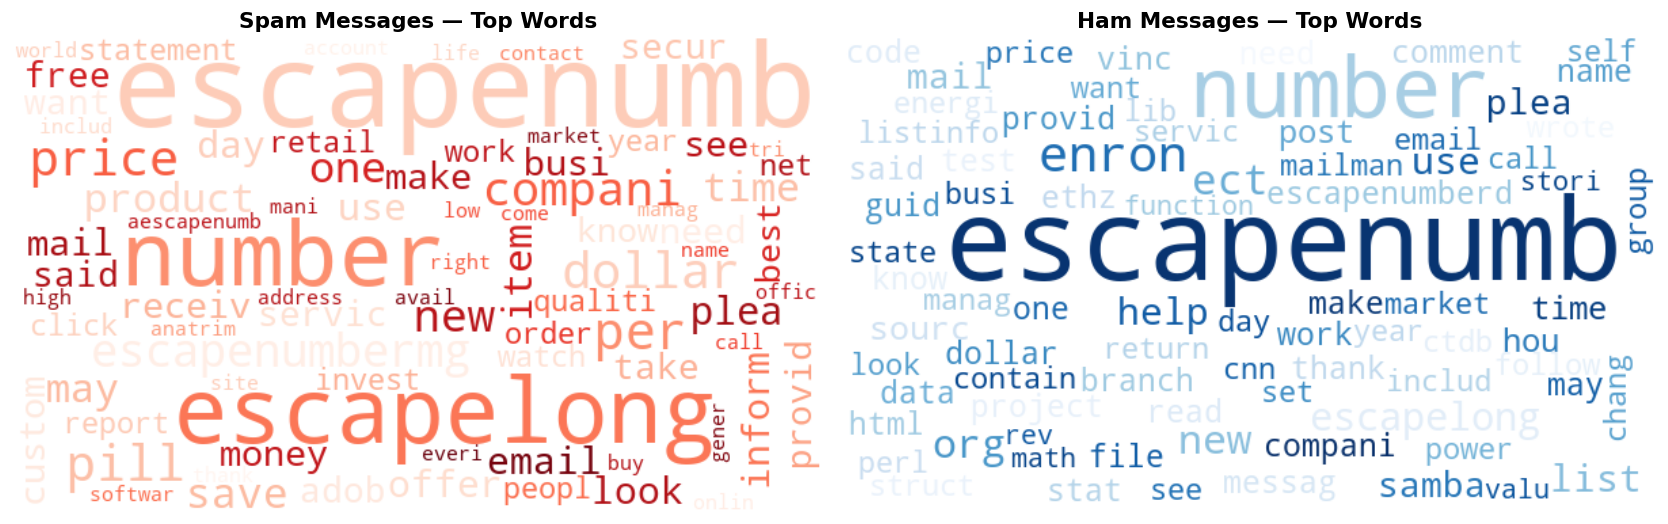

In [13]:
# ── 4.4 Word clouds ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label_val, color, title in [
        (axes[0], 1, 'Reds',  'Spam Messages — Top Words'),
        (axes[1], 0, 'Blues', 'Ham Messages — Top Words')]:
    text_combined = ' '.join(df[df['spam'] == label_val]['text_clean'])
    wc = WordCloud(width=600, height=350, background_color='white',
                   colormap=color, max_words=80, collocations=False).generate(text_combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('figures/04_word_clouds.png', bbox_inches='tight')
plt.show()


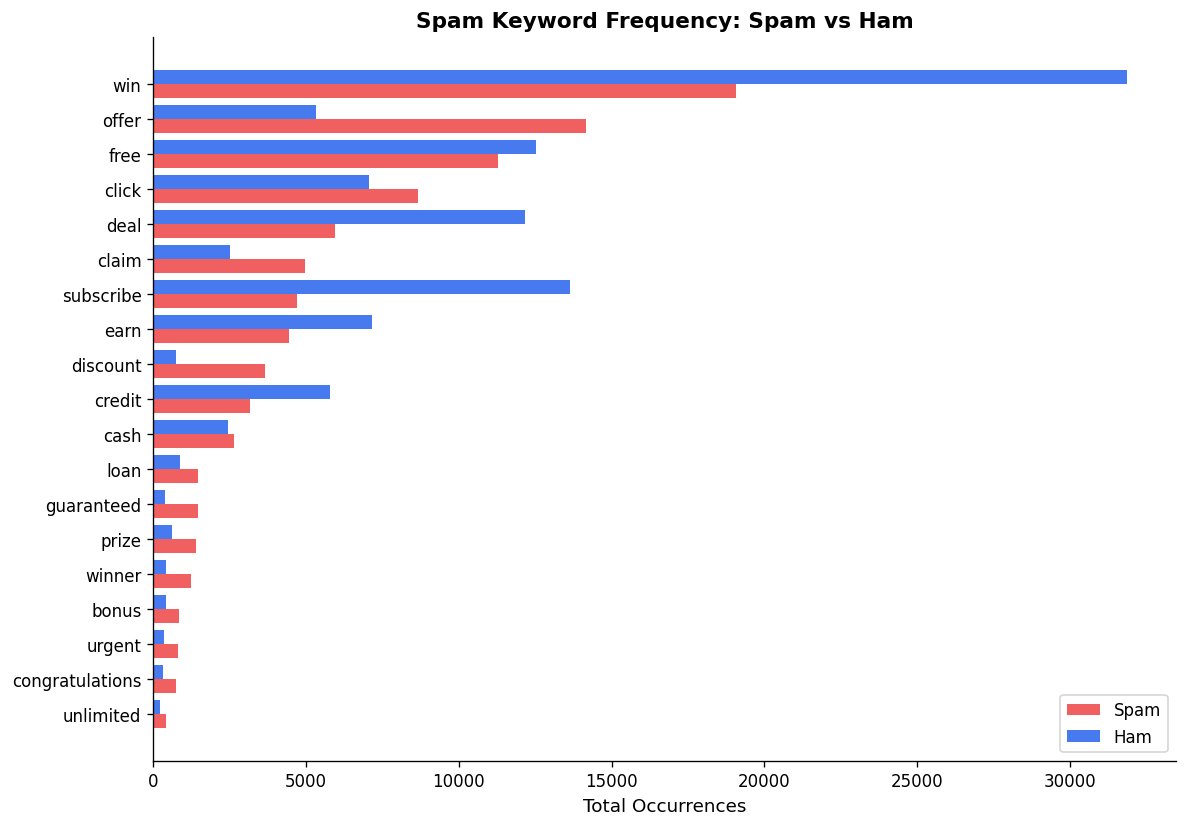

In [14]:
# ── 4.5 Spam keyword frequency ───────────────────────────
kw_spam = {kw: df[df['spam']==1]['text'].str.lower().str.count(kw).sum()
           for kw in SPAM_KEYWORDS}
kw_ham  = {kw: df[df['spam']==0]['text'].str.lower().str.count(kw).sum()
           for kw in SPAM_KEYWORDS}

kw_df = pd.DataFrame({'Spam': kw_spam, 'Ham': kw_ham}).sort_values('Spam', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
x = np.arange(len(kw_df))
width = 0.4
ax.barh(x - width/2, kw_df['Spam'], width, color=PALETTE['spam'], label='Spam', alpha=0.85)
ax.barh(x + width/2, kw_df['Ham'],  width, color=PALETTE['ham'],  label='Ham',  alpha=0.85)
ax.set_yticks(x)
ax.set_yticklabels(kw_df.index)
ax.set_xlabel('Total Occurrences')
ax.set_title('Spam Keyword Frequency: Spam vs Ham', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('figures/05_keyword_frequency.png', bbox_inches='tight')
plt.show()


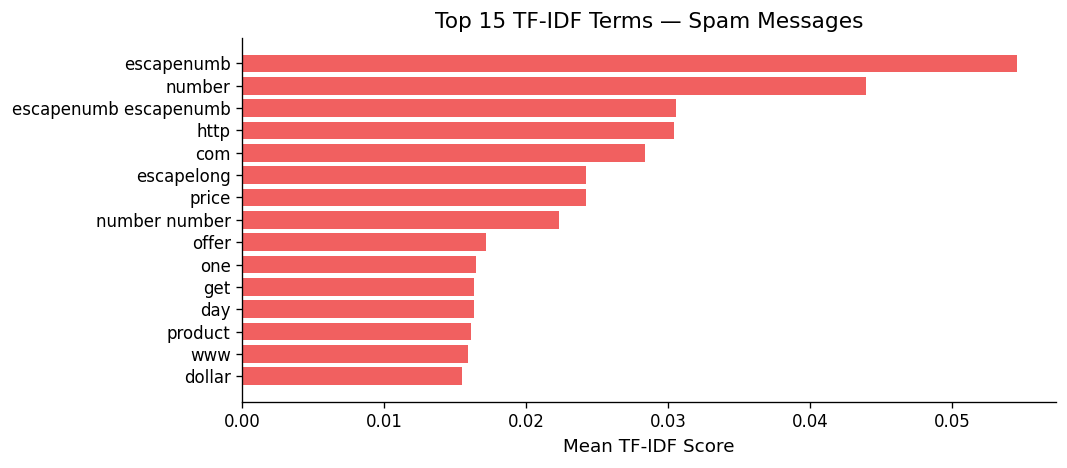

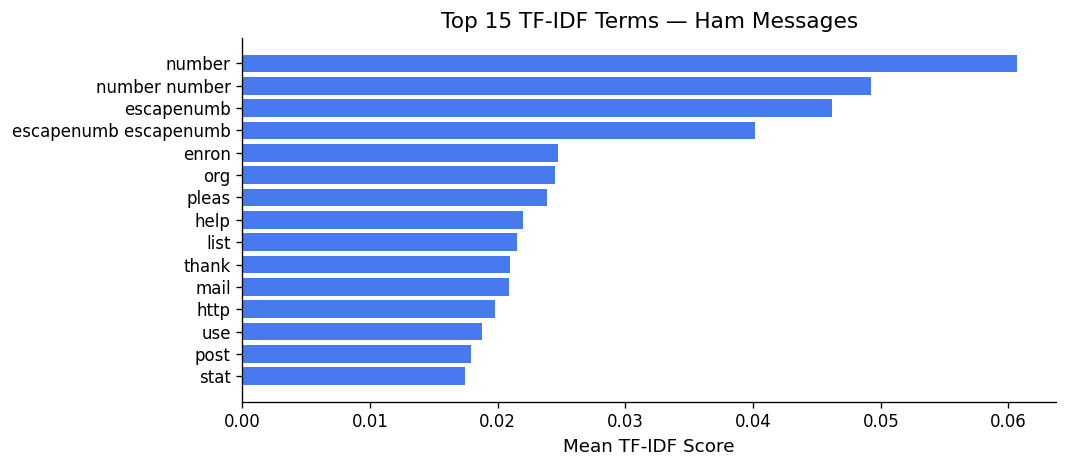

In [15]:
# ── 4.6 Top TF-IDF terms per class ──────────────────────
tfidf_dense = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

top_n = 15
for cls, name, color in [(1,'Spam',PALETTE['spam']), (0,'Ham',PALETTE['ham'])]:
    idx = df[df['spam'] == cls].index
    # Intersect with valid TF-IDF index range
    idx = [i for i in idx if i < tfidf_dense.shape[0]]
    means = tfidf_dense.iloc[idx].mean().sort_values(ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.barh(means.index[::-1], means.values[::-1], color=color, alpha=0.85)
    ax.set_xlabel('Mean TF-IDF Score')
    ax.set_title(f'Top {top_n} TF-IDF Terms — {name} Messages')
    plt.tight_layout()
    plt.savefig(f'figures/06_tfidf_top_{name.lower()}.png', bbox_inches='tight')
    plt.show()


## 5. Machine Learning — Classification Models

Four classifiers are trained and compared:
- **Naive Bayes** — probabilistic baseline, well-suited to text classification
- **Logistic Regression** — linear classifier, interpretable, fast
- **Linear SVM** — high-dimensional text data, strong generalisation
- **Random Forest** — ensemble method, captures non-linear patterns


In [16]:
# ── Helper: evaluate a classifier ────────────────────────
def evaluate_classifier(name, model, X_tr, X_te, y_tr, y_te):
    """Fit, predict, return metrics dict."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Probability scores for ROC (use decision_function if no predict_proba)
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_te)[:, 1]
    else:
        y_score = model.decision_function(X_te)

    cv  = cross_val_score(model, X_tr, y_tr, cv=StratifiedKFold(5),
                          scoring='f1', n_jobs=-1)
    return {
        'Model'    : name,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall'   : recall_score(y_te, y_pred),
        'F1'       : f1_score(y_te, y_pred),
        'ROC-AUC'  : roc_auc_score(y_te, y_score),
        'CV F1 Mean': cv.mean(),
        'CV F1 Std' : cv.std(),
        '_model'   : model,
        '_y_pred'  : y_pred,
        '_y_score' : y_score,
    }

print("Helper function defined ✅")


Helper function defined ✅


In [17]:
# ── 5.1 Train all classifiers ────────────────────────────
clf_results = []

print("Training Naive Bayes...")
clf_results.append(evaluate_classifier(
    'Naive Bayes', MultinomialNB(alpha=0.1),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

print("Training Logistic Regression...")
clf_results.append(evaluate_classifier(
    'Logistic Regression', LogisticRegression(C=1.0, max_iter=1000, random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

print("Training Linear SVM...")
clf_results.append(evaluate_classifier(
    'Linear SVM', LinearSVC(C=1.0, max_iter=2000, random_state=42),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

print("Training Random Forest...")
clf_results.append(evaluate_classifier(
    'Random Forest', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_train_tfidf, X_test_tfidf, y_train, y_test))

print("\n✅ All classifiers trained.")


Training Naive Bayes...
Training Logistic Regression...
Training Linear SVM...
Training Random Forest...

✅ All classifiers trained.


In [18]:
# ── 5.2 Classification results table ─────────────────────
metric_cols = ['Model','Accuracy','Precision','Recall','F1','ROC-AUC','CV F1 Mean','CV F1 Std']
clf_df = pd.DataFrame([{k: r[k] for k in metric_cols} for r in clf_results])
clf_df_display = clf_df.set_index('Model')
print("Classification Model Comparison:")
print(clf_df_display.round(4).to_string())

# Highlight best model
best_clf_name = clf_df.loc[clf_df['F1'].idxmax(), 'Model']
print(f"\n🏆 Best classifier by F1: {best_clf_name} ({clf_df['F1'].max():.4f})")


Classification Model Comparison:
                     Accuracy  Precision  Recall      F1  ROC-AUC  CV F1 Mean  CV F1 Std
Model                                                                                   
Naive Bayes            0.9341     0.9171  0.9506  0.9335   0.9868      0.9367     0.0019
Logistic Regression    0.9651     0.9601  0.9685  0.9643   0.9950      0.9646     0.0016
Linear SVM             0.9691     0.9682  0.9683  0.9683   0.9956      0.9687     0.0011
Random Forest          0.9746     0.9696  0.9785  0.9740   0.9965      0.9748     0.0006

🏆 Best classifier by F1: Random Forest (0.9740)


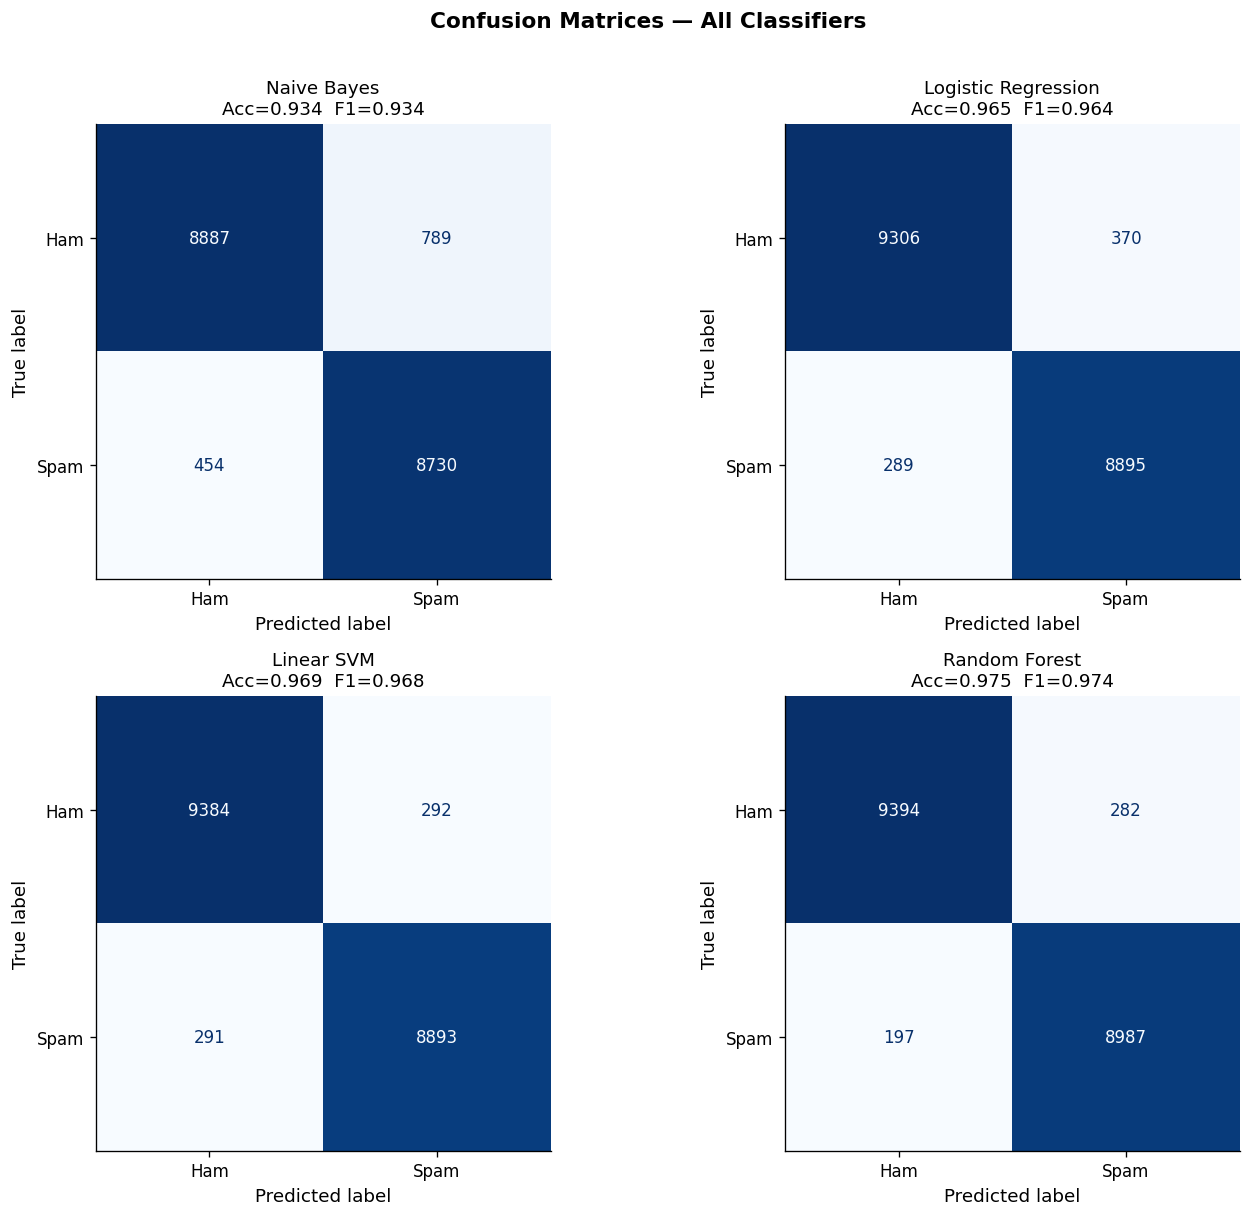

In [19]:
# ── 5.3 Confusion matrices ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, r in zip(axes, clf_results):
    cm = confusion_matrix(y_test, r['_y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = r['Accuracy']
    f1  = r['F1']
    ax.set_title(f"{r['Model']}\nAcc={acc:.3f}  F1={f1:.3f}", fontsize=11)

plt.suptitle('Confusion Matrices — All Classifiers', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/07_confusion_matrices.png', bbox_inches='tight')
plt.show()


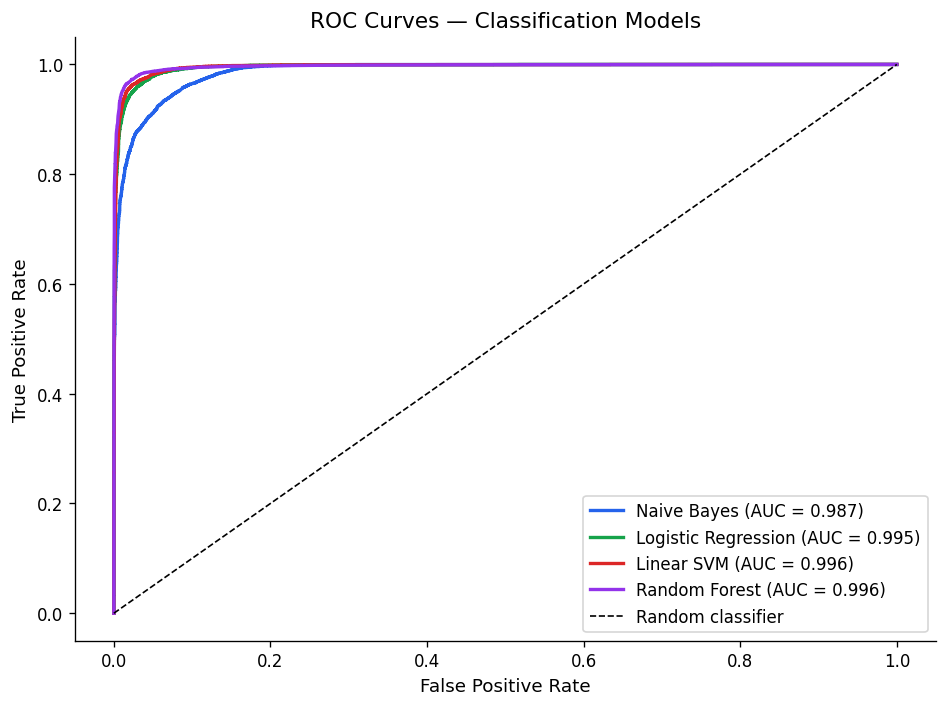

In [20]:
# ── 5.4 ROC curves ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ['#2563eb','#16a34a','#dc2626','#9333ea']

for r, c in zip(clf_results, colors_roc):
    fpr, tpr, _ = roc_curve(y_test, r['_y_score'])
    ax.plot(fpr, tpr, color=c, lw=2,
            label=f"{r['Model']} (AUC = {r['ROC-AUC']:.3f})")

ax.plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Classification Models')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/08_roc_curves.png', bbox_inches='tight')
plt.show()


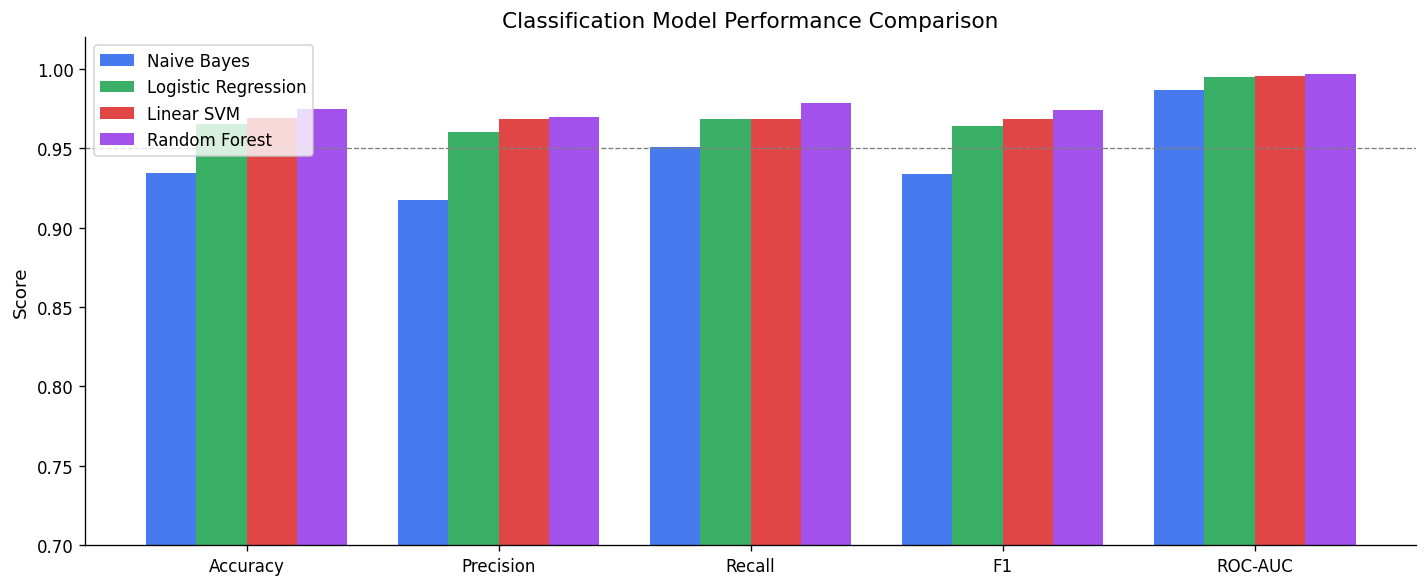

In [21]:
# ── 5.5 Model metric comparison bar chart ────────────────
metrics_to_plot = ['Accuracy','Precision','Recall','F1','ROC-AUC']
x = np.arange(len(metrics_to_plot))
width = 0.2
bar_colors = ['#2563eb','#16a34a','#dc2626','#9333ea']

fig, ax = plt.subplots(figsize=(12, 5))
for i, r in enumerate(clf_results):
    vals = [r[m] for m in metrics_to_plot]
    ax.bar(x + i*width, vals, width, label=r['Model'], color=bar_colors[i], alpha=0.85)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(metrics_to_plot)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('Score')
ax.set_title('Classification Model Performance Comparison')
ax.legend()
ax.axhline(0.95, color='gray', linestyle='--', linewidth=0.8, label='HD target (0.95)')
plt.tight_layout()
plt.savefig('figures/09_model_comparison.png', bbox_inches='tight')
plt.show()


## 6. Machine Learning — Regression Model

**Objective:** Predict a continuous *spam risk score* (0.0 – 1.0) for each message.  
This score is derived from engineered features (exclamation count, dollar signs, keyword density, etc.) and provides a graduated threat level rather than a binary label — useful for ranking messages by risk.

Two regression models are compared: **Ridge Regression** (linear baseline) and **Gradient Boosting Regressor** (non-linear ensemble).


In [22]:
# ── 6.1 Build regression target (spam risk score) ────────
# Normalise each contributing feature 0-1 then compute weighted average
df['spam_risk_score'] = (
    0.30 * MinMaxScaler().fit_transform(df[['spam_keyword_count']]).flatten() +
    0.20 * MinMaxScaler().fit_transform(df[['exclaim_count']]).flatten()    +
    0.20 * MinMaxScaler().fit_transform(df[['dollar_count']]).flatten()     +
    0.15 * MinMaxScaler().fit_transform(df[['upper_ratio']]).flatten()      +
    0.15 * df['spam'].values   # anchor on true label
)
# Clip to [0,1]
df['spam_risk_score'] = df['spam_risk_score'].clip(0, 1)

print("Spam risk score statistics:")
print(df.groupby('spam')['spam_risk_score'].describe().round(3))


Spam risk score statistics:
        count   mean    std   min   25%   50%    75%    max
spam                                                       
0     48381.0  0.021  0.028  0.00  0.00  0.02  0.027  0.408
1     45917.0  0.177  0.032  0.15  0.15  0.17  0.190  0.559


In [23]:
# ── 6.2 Regression train/test split ──────────────────────
y_reg = df['spam_risk_score'].values

X_tr_reg, X_te_reg, y_tr_reg, y_te_reg = train_test_split(
    X_numeric_scaled, y_reg, test_size=0.2, random_state=42)

print(f"Regression train: {len(X_tr_reg):,}  test: {len(X_te_reg):,}")


Regression train: 75,438  test: 18,860


In [24]:
# ── 6.3 Train regression models ──────────────────────────
def eval_regressor(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'MAE' : mean_absolute_error(y_te, y_pred),
        'MSE' : mean_squared_error(y_te, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_te, y_pred)),
        'R²'  : r2_score(y_te, y_pred),
        '_model' : model,
        '_y_pred': y_pred,
    }

reg_results = []

print("Training Ridge Regression...")
reg_results.append(eval_regressor(
    'Ridge Regression',
    Ridge(alpha=1.0),
    X_tr_reg, X_te_reg, y_tr_reg, y_te_reg))

print("Training Gradient Boosting Regressor...")
reg_results.append(eval_regressor(
    'Gradient Boosting',
    GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42),
    X_tr_reg, X_te_reg, y_tr_reg, y_te_reg))

reg_df = pd.DataFrame([{k: r[k] for k in ['Model','MAE','MSE','RMSE','R²']}
                        for r in reg_results])
print("\nRegression Model Comparison:")
print(reg_df.set_index('Model').round(4).to_string())
best_reg = reg_df.loc[reg_df['R²'].idxmax(), 'Model']
print(f"\n🏆 Best regressor by R²: {best_reg}")


Training Ridge Regression...
Training Gradient Boosting Regressor...

Regression Model Comparison:
                      MAE     MSE    RMSE      R²
Model                                            
Ridge Regression   0.0701  0.0051  0.0716  0.2718
Gradient Boosting  0.0464  0.0032  0.0566  0.5448

🏆 Best regressor by R²: Gradient Boosting


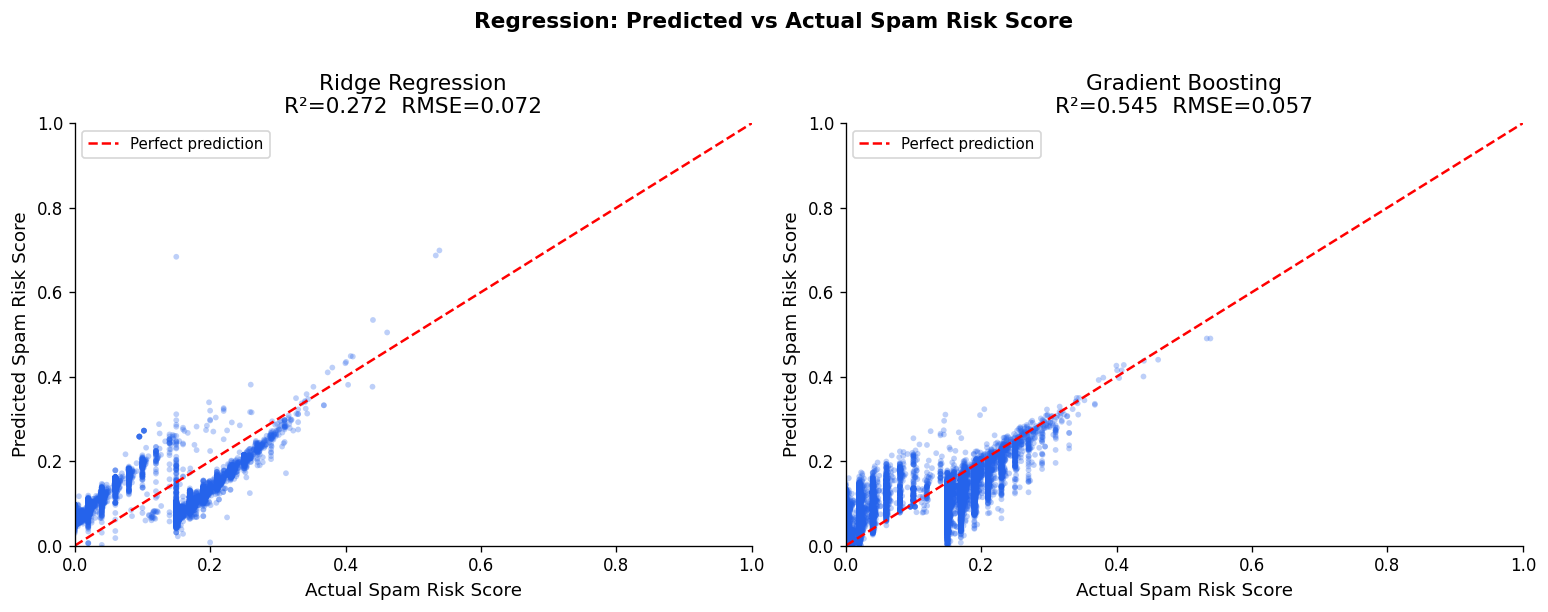

In [25]:
# ── 6.4 Regression visualisations ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, r in zip(axes, reg_results):
    ax.scatter(y_te_reg, r['_y_pred'], alpha=0.3, s=12,
               color='#2563eb', edgecolors='none')
    lims = [0, 1]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
    ax.set_xlabel('Actual Spam Risk Score')
    ax.set_ylabel('Predicted Spam Risk Score')
    ax.set_title(f"{r['Model']}\nR²={r['R²']:.3f}  RMSE={r['RMSE']:.3f}")
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(fontsize=9)

plt.suptitle('Regression: Predicted vs Actual Spam Risk Score',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/10_regression_scatter.png', bbox_inches='tight')
plt.show()


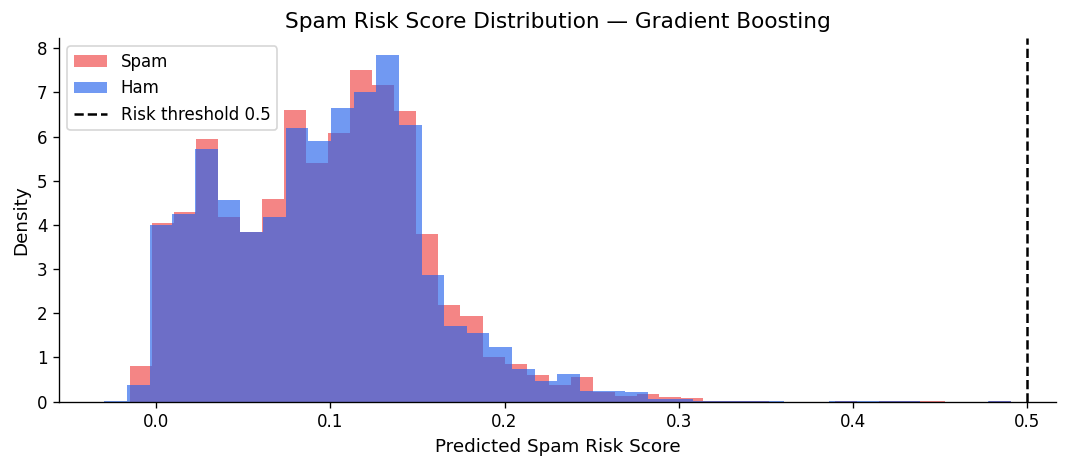

In [26]:
# ── 6.5 Risk score distribution ──────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
best_reg_result = reg_results[reg_df['R²'].idxmax()]
pred_scores = best_reg_result['_y_pred']

ax.hist(pred_scores[y_test[:len(pred_scores)]==1], bins=40, alpha=0.65,
        color=PALETTE['spam'], label='Spam', density=True)
ax.hist(pred_scores[y_test[:len(pred_scores)]==0], bins=40, alpha=0.65,
        color=PALETTE['ham'],  label='Ham',  density=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Risk threshold 0.5')
ax.set_xlabel('Predicted Spam Risk Score')
ax.set_ylabel('Density')
ax.set_title(f'Spam Risk Score Distribution — {best_reg_result["Model"]}')
ax.legend()
plt.tight_layout()
plt.savefig('figures/11_risk_score_distribution.png', bbox_inches='tight')
plt.show()


## 7. Machine Learning — Clustering (K-Means)

**Objective:** Discover natural spam pattern groups without using labels.  
TF-IDF vectors are reduced to 50 dimensions using Truncated SVD (LSA) before K-Means clustering. This reveals thematic clusters (e.g., financial fraud, prize scams, phishing) within spam messages.


In [27]:
# ── 7.1 Dimensionality reduction (LSA) ───────────────────
N_COMPONENTS = 50
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
X_lsa = svd.fit_transform(X_tfidf)

explained = svd.explained_variance_ratio_.sum()
print(f"LSA with {N_COMPONENTS} components explains "
      f"{explained:.1%} of total variance")


LSA with 50 components explains 23.7% of total variance


Computing elbow curve (this may take a minute)...
  K=2  inertia=19232  silhouette=0.244
  K=3  inertia=17893  silhouette=0.111
  K=4  inertia=17143  silhouette=0.135
  K=5  inertia=16410  silhouette=0.155
  K=6  inertia=15895  silhouette=0.134
  K=7  inertia=15394  silhouette=0.124
  K=8  inertia=14828  silhouette=0.148
  K=9  inertia=14431  silhouette=0.152
  K=10  inertia=13803  silhouette=0.158


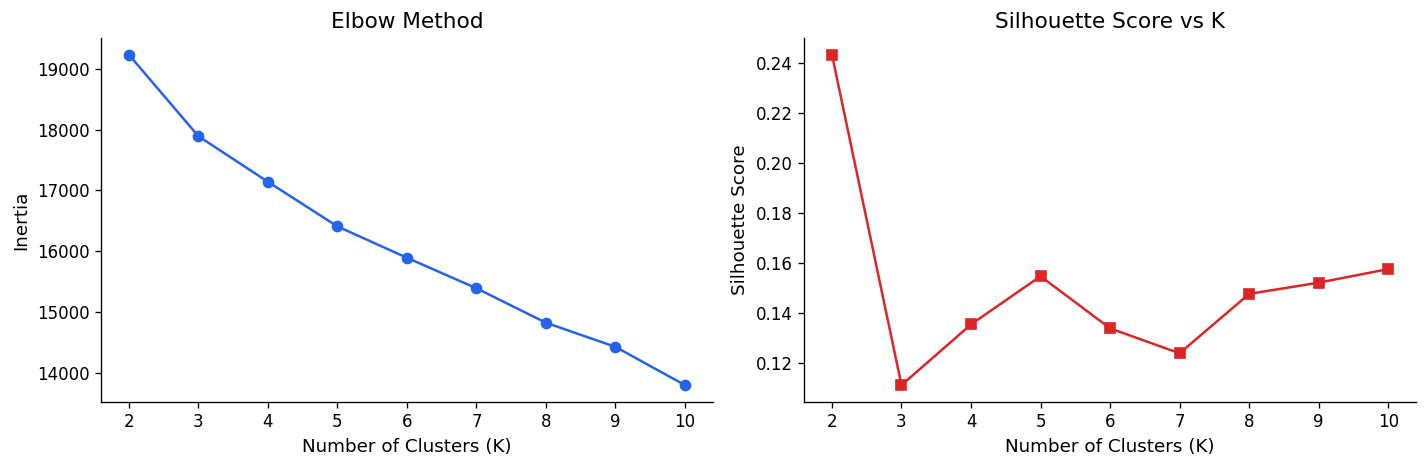


🏆 Best K by silhouette score: 2


In [28]:
# ── 7.2 Elbow method — optimal K ─────────────────────────
inertias     = []
sil_scores   = []
K_range      = range(2, 11)

print("Computing elbow curve (this may take a minute)...")
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_lsa)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_lsa, km.labels_, sample_size=2000))
    print(f"  K={k}  inertia={km.inertia_:.0f}  silhouette={sil_scores[-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='#2563eb')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[1].plot(list(K_range), sil_scores, 's-', color='#dc2626')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K')
plt.tight_layout()
plt.savefig('figures/12_kmeans_elbow.png', bbox_inches='tight')
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"\n🏆 Best K by silhouette score: {best_k}")


In [29]:
# ── 7.3 Final K-Means model ──────────────────────────────
BEST_K = best_k
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_lsa)

print("Cluster composition (spam vs ham):")
cluster_comp = df.groupby('cluster')['spam'].agg(['sum','count','mean'])
cluster_comp.columns = ['Spam Count','Total','Spam Rate']
cluster_comp['Ham Count'] = cluster_comp['Total'] - cluster_comp['Spam Count']
print(cluster_comp.round(3))


Cluster composition (spam vs ham):
         Spam Count  Total  Spam Rate  Ham Count
cluster                                         
0             45917  88008      0.522      42091
1                 0   6290      0.000       6290


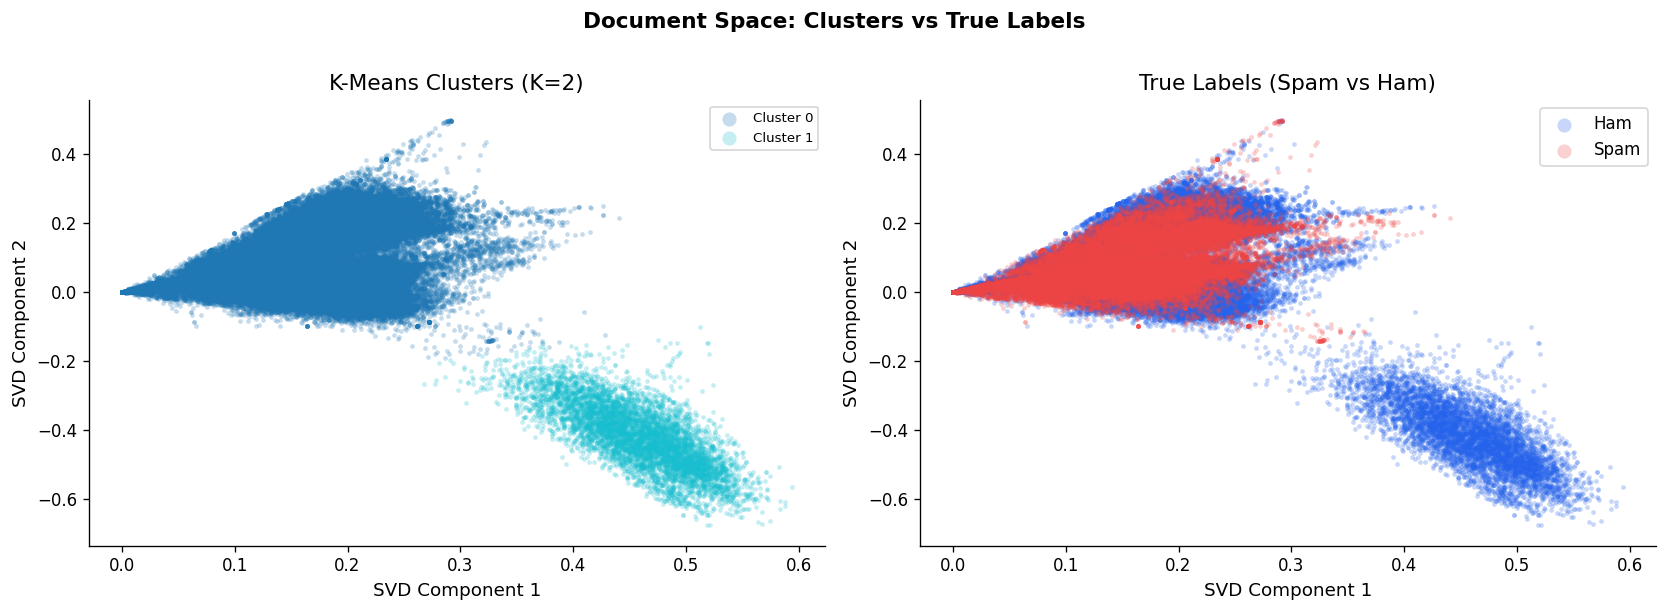

In [30]:
# ── 7.4 Cluster visualisation (2D SVD projection) ────────
svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(X_tfidf)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter_kw = dict(alpha=0.25, s=8, linewidths=0)

# Coloured by cluster
cmap_clust = plt.cm.get_cmap('tab10', BEST_K)
for k in range(BEST_K):
    mask = df['cluster'] == k
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    color=cmap_clust(k), label=f'Cluster {k}', **scatter_kw)
axes[0].set_title(f'K-Means Clusters (K={BEST_K})')
axes[0].set_xlabel('SVD Component 1')
axes[0].set_ylabel('SVD Component 2')
axes[0].legend(markerscale=3, fontsize=8)

# Coloured by true label
for lbl, name, color in [(0,'Ham',PALETTE['ham']),(1,'Spam',PALETTE['spam'])]:
    mask = df['spam'] == lbl
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    color=color, label=name, **scatter_kw)
axes[1].set_title('True Labels (Spam vs Ham)')
axes[1].set_xlabel('SVD Component 1')
axes[1].set_ylabel('SVD Component 2')
axes[1].legend(markerscale=3)

plt.suptitle('Document Space: Clusters vs True Labels',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/13_cluster_visualisation.png', bbox_inches='tight')
plt.show()


In [31]:
# ── 7.5 Top terms per cluster ────────────────────────────
feature_names = tfidf.get_feature_names_out()
print(f"Top 10 terms per cluster (K={BEST_K}):\n")
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

# Map cluster labels back from LSA space via centroid projection
# Use original TF-IDF centroids approximated via mean
for k in range(BEST_K):
    idx = df[df['cluster'] == k].index
    # Filter indices within TF-IDF matrix bounds
    idx_valid = [i for i in idx if i < X_tfidf.shape[0]]
    if not idx_valid:
        continue
    centroid = np.asarray(X_tfidf[idx_valid].mean(axis=0)).flatten()
    top_idx  = centroid.argsort()[::-1][:10]
    top_words = [feature_names[i] for i in top_idx]
    spam_rate = df.loc[idx, 'spam'].mean()
    print(f"Cluster {k} (spam rate: {spam_rate:.1%}): {', '.join(top_words)}")


Top 10 terms per cluster (K=2):

Cluster 0 (spam rate: 52.2%): number, escapenumb, number number, escapenumb escapenumb, http, com, escapelong, pleas, get, price
Cluster 1 (spam rate: 0.0%): stat, ethz, post guid, guid, post, escapenumb, help, escapenumb escapenumb, math ethz, stat math


## 8. Final Model Comparison & Summary

In [32]:
# ── 8.1 Complete results summary table ───────────────────
print("=" * 65)
print("CLASSIFICATION MODEL SUMMARY")
print("=" * 65)
print(clf_df.set_index('Model')[['Accuracy','Precision','Recall','F1','ROC-AUC']].round(4).to_string())
print()
print("=" * 65)
print("REGRESSION MODEL SUMMARY")
print("=" * 65)
print(reg_df.set_index('Model')[['MAE','RMSE','R²']].round(4).to_string())
print()
print("=" * 65)
print("CLUSTERING SUMMARY")
print("=" * 65)
final_sil = silhouette_score(X_lsa, df['cluster'], sample_size=2000)
print(f"K-Means  K={BEST_K}  Silhouette Score = {final_sil:.4f}")


CLASSIFICATION MODEL SUMMARY
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Naive Bayes            0.9341     0.9171  0.9506  0.9335   0.9868
Logistic Regression    0.9651     0.9601  0.9685  0.9643   0.9950
Linear SVM             0.9691     0.9682  0.9683  0.9683   0.9956
Random Forest          0.9746     0.9696  0.9785  0.9740   0.9965

REGRESSION MODEL SUMMARY
                      MAE    RMSE      R²
Model                                    
Ridge Regression   0.0701  0.0716  0.2718
Gradient Boosting  0.0464  0.0566  0.5448

CLUSTERING SUMMARY
K-Means  K=2  Silhouette Score = 0.2597


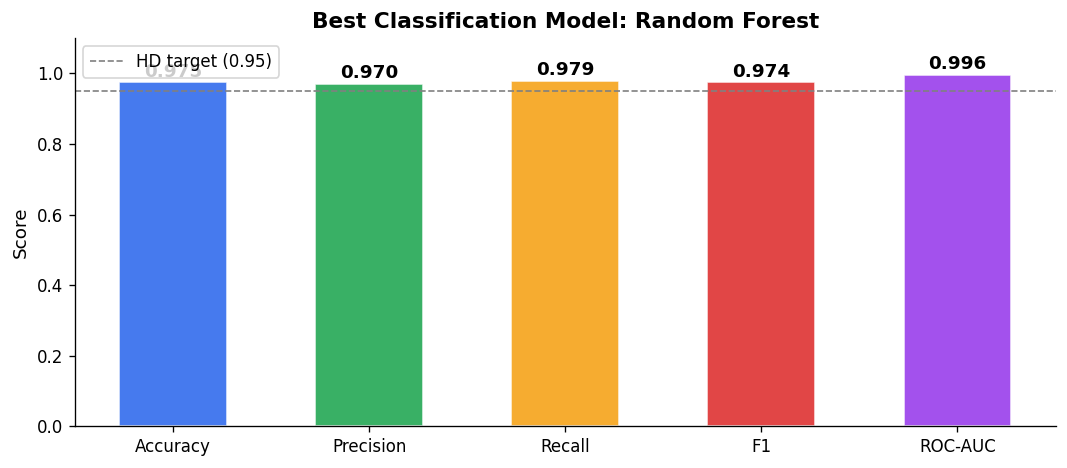

In [33]:
# ── 8.2 Final best model summary visual ──────────────────
best_clf = [r for r in clf_results if r['Model'] == best_clf_name][0]
metrics  = ['Accuracy','Precision','Recall','F1','ROC-AUC']
values   = [best_clf[m] for m in metrics]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(metrics, values,
              color=['#2563eb','#16a34a','#f59e0b','#dc2626','#9333ea'],
              alpha=0.85, edgecolor='white', width=0.55)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.axhline(0.95, color='gray', linestyle='--', lw=1, label='HD target (0.95)')
ax.set_title(f'Best Classification Model: {best_clf_name}', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.legend()
plt.tight_layout()
plt.savefig('figures/14_best_model_summary.png', bbox_inches='tight')
plt.show()


## 9. Export Processed Data & Models

In [34]:
# ── 9.1 Save processed dataset ───────────────────────────
os.makedirs('../data',    exist_ok=True)
os.makedirs('../models',  exist_ok=True)
os.makedirs('../figures', exist_ok=True)
os.makedirs('data',    exist_ok=True)
os.makedirs('models',  exist_ok=True)
os.makedirs('figures', exist_ok=True)

export_cols = ['text', 'text_clean', 'spam', 'source',
               'char_count', 'word_count', 'exclaim_count',
               'dollar_count', 'upper_ratio', 'url_count',
               'avg_word_len', 'spam_keyword_count',
               'spam_risk_score', 'cluster']

# Save to both locations
df[export_cols].to_csv('../data/spam_processed.csv', index=False)
df[export_cols].to_csv('data/spam_processed.csv', index=False)
print(f"Processed dataset saved: {len(df):,} rows")
print(f"  -> ../data/spam_processed.csv")
print(f"  -> data/spam_processed.csv")


Processed dataset saved: 94,298 rows
  -> ../data/spam_processed.csv
  -> data/spam_processed.csv


In [35]:
# ── 9.2 Save ML models ───────────────────────────────────
# Best classifier
best_clf_obj = [r['_model'] for r in clf_results if r['Model'] == best_clf_name][0]

# Save to both locations (notebooks/models and root models)
for model_dir in ['models', '../models']:
    os.makedirs(model_dir, exist_ok=True)
    joblib.dump(best_clf_obj, f'{model_dir}/classifier.pkl')
    joblib.dump(tfidf,        f'{model_dir}/tfidf_vectorizer.pkl')
    joblib.dump(scaler,       f'{model_dir}/scaler.pkl')
    joblib.dump(kmeans,       f'{model_dir}/kmeans.pkl')
    joblib.dump(svd,          f'{model_dir}/svd_lsa.pkl')
    best_reg_obj = [r['_model'] for r in reg_results if r['Model'] == best_reg][0]
    joblib.dump(best_reg_obj, f'{model_dir}/regressor.pkl')

print('Models saved to models/ and ../models/')
print()
for f_name in os.listdir('models'):
    size = os.path.getsize(f'models/{f_name}') / 1024
    print(f'   models/{f_name}  ({size:.1f} KB)')


Models saved to models/ and ../models/

   models/classifier.pkl  (80585.4 KB)
   models/kmeans.pkl  (369.9 KB)
   models/regressor.pkl  (249.9 KB)
   models/scaler.pkl  (1.0 KB)
   models/svd_lsa.pkl  (1955.0 KB)
   models/tfidf_vectorizer.pkl  (184.9 KB)


In [36]:
# ── Save 4 individual classification models ──────────────
for r in clf_results:
    model_map = {
        'Naive Bayes'        : 'classifier_nb.pkl',
        'Logistic Regression': 'classifier_lr.pkl',
        'Linear SVM'         : 'classifier_svm.pkl',
        'Random Forest'      : 'classifier_rf.pkl',
    }
    if r['Model'] in model_map:
        fname = model_map[r['Model']]
        for model_dir in ['models', '../models']:
            joblib.dump(r['_model'], f'{model_dir}/{fname}')
        print(f"Saved: {fname}")

print()
print("All 4 individual models saved!")
print()
print("Final models/ folder:")
for f_name in sorted(os.listdir('models')):
    size = os.path.getsize(f'models/{f_name}') / 1024
    print(f"   {f_name:<35} ({size:.1f} KB)")


Saved: classifier_nb.pkl
Saved: classifier_lr.pkl
Saved: classifier_svm.pkl
Saved: classifier_rf.pkl

All 4 individual models saved!

Final models/ folder:
   classifier.pkl                      (80585.4 KB)
   classifier_lr.pkl                   (39.9 KB)
   classifier_nb.pkl                   (157.0 KB)
   classifier_rf.pkl                   (80585.4 KB)
   classifier_svm.pkl                  (39.8 KB)
   kmeans.pkl                          (369.9 KB)
   regressor.pkl                       (249.9 KB)
   scaler.pkl                          (1.0 KB)
   svd_lsa.pkl                         (1955.0 KB)
   tfidf_vectorizer.pkl                (184.9 KB)


In [37]:
# ── 9.3 Quick prediction demo ────────────────────────────
def predict_spam(text: str) -> dict:
    """Full prediction pipeline using saved models."""
    clean = preprocess_text(text)
    vec   = tfidf.transform([clean])

    # Classification
    clf_label = best_clf_obj.predict(vec)[0]
    if hasattr(best_clf_obj, 'predict_proba'):
        clf_conf = best_clf_obj.predict_proba(vec)[0][1]
    else:
        clf_conf = float(best_clf_obj.decision_function(vec)[0])

    # Risk score (regression)
    feat = np.array([[
        len(text), len(text.split()),
        text.count('!'), text.count('$'),
        sum(1 for c in text if c.isupper()) / max(len(text),1),
        text.lower().count('http') + text.lower().count('www'),
        np.mean([len(w) for w in text.split()]) if text.split() else 0,
        sum(1 for kw in SPAM_KEYWORDS if kw in text.lower())
    ]])
    feat_scaled = scaler.transform(feat)
    risk_score  = float(best_reg_obj.predict(feat_scaled)[0])

    return {
        'label'      : 'SPAM' if clf_label == 1 else 'HAM',
        'confidence' : round(float(clf_conf), 4),
        'risk_score' : round(np.clip(risk_score, 0, 1), 4),
    }

# Test
samples = [
    "Congratulations! You have won a $1,000,000 prize. Click here to claim now!",
    "Hey, are you coming to the study group meeting tomorrow at 3pm?",
    "FREE entry!! Win a brand new iPhone 16. Limited time offer — act NOW!!!"
]
print("─" * 60)
for s in samples:
    result = predict_spam(s)
    print(f"Text   : {s[:60]}...")
    print(f"Result : {result}")
    print("─" * 60)


────────────────────────────────────────────────────────────
Text   : Congratulations! You have won a $1,000,000 prize. Click here...
Result : {'label': 'SPAM', 'confidence': 0.87, 'risk_score': np.float64(0.2179)}
────────────────────────────────────────────────────────────
Text   : Hey, are you coming to the study group meeting tomorrow at 3...
Result : {'label': 'HAM', 'confidence': 0.04, 'risk_score': np.float64(0.0118)}
────────────────────────────────────────────────────────────
Text   : FREE entry!! Win a brand new iPhone 16. Limited time offer —...
Result : {'label': 'SPAM', 'confidence': 0.95, 'risk_score': np.float64(0.208)}
────────────────────────────────────────────────────────────


## Notebook Complete

### Datasets Used
| # | Dataset | Source | Records |
|---|---------|--------|---------|
| 1 | Lecturer Basic Dataset | Canvas emails.csv | 5,728 |
| 2 | UCI SMS Spam Collection | Kaggle team-ai | 5,572 |
| 3 | Combined Spam Dataset | Kaggle meruvulikith | 83,448 |
| | **Total** | | **~94,748** |

### All outputs saved:
- `data/spam_processed.csv` — cleaned dataset for ZIP submission
- `models/classifier.pkl` — best classification model
- `models/classifier_nb.pkl` — Naive Bayes
- `models/classifier_lr.pkl` — Logistic Regression
- `models/classifier_svm.pkl` — Linear SVM
- `models/classifier_rf.pkl` — Random Forest
- `models/tfidf_vectorizer.pkl` — fitted TF-IDF vectoriser
- `models/regressor.pkl` — spam risk score regressor
- `models/kmeans.pkl` — clustering model
- `models/scaler.pkl` — feature scaler
- `figures/` — all 14 visualisation figures
